In [1]:
#This script is for getting basic land cover map for a region of interest.
import geemap
import ee
import subprocess  # For installing libraries

Map = geemap.Map()
Map.add_basemap('HYBRID')

Dynamic_World = ee.ImageCollection('GOOGLE/DYNAMICWORLD/V1')
roi = ee.FeatureCollection("projects/ee-clivedcosta/assets/Discreteplots")
Map.centerObject(roi)
scale = 10

start_date = '2016-02-02'
end_date = '2025-06-01'

images = geemap.dynamic_world_timeseries(
    roi, start_date, end_date, return_type="class"
)

vis_params = {'bands': ['label'], 'palette': [
    '#419BDF', '#397D49', '#88B053', '#7A87C6', '#E49635', '#DFC35A',
    '#C4281B', '#A59B8F', '#B39FE1'
], 'min': 0, 'max': 8}

first_image = images.first()

def image_to_feature_collection(image, roi, scale):
    features = []
    for i in range(9):
        class_mask = image.eq(i)
        class_vectors = class_mask.reduceToVectors(
            geometry=roi,
            geometryType='centroid',  # or 'polygon'
            scale=scale,
            crs = 'EPSG:4326'
        )
        features.append(class_vectors.filter(ee.Filter.neq('label', None)).map(lambda f: f.set('class', i)))
    return ee.FeatureCollection(features).flatten()

feature_collection = image_to_feature_collection(first_image, roi, scale)


Map.addLayer(images.first(), vis_params, 'First image')
Map.ts_inspector(images, left_vis=vis_params, date_format='YYYY')
Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=Dropdown(layout=Layo…

In [2]:
# Enhanced Eligibility Analysis - Continuous Forest & 2m Canopy
import geemap
import ee
from datetime import datetime

# Initialize Earth Engine
ee.Initialize()

Map = geemap.Map()
Map.add_basemap('HYBRID')

Dynamic_World = ee.ImageCollection('GOOGLE/DYNAMICWORLD/V1')
roi = ee.FeatureCollection("projects/ee-clivedcosta/assets/Discreteplots")
Map.centerObject(roi)
scale = 10

# Define analysis period (2016-2024)
analysis_years = list(range(2016, 2025))

def get_yearly_landcover(year):
    """Get annual land cover classification"""
    start_date = f'{year}-01-01'
    end_date = f'{year}-12-31'
    
    yearly_data = Dynamic_World.filterBounds(roi) \
        .filterDate(start_date, end_date) \
        .select('label') \
        .mode()
    
    return yearly_data

# Generate yearly land cover
print("Processing land cover data 2016-2024...")
yearly_landcover = {}
for year in analysis_years:
    yearly_landcover[year] = get_yearly_landcover(year)

# Create forest masks for each year
forest_masks = {}
for year in analysis_years:
    forest_masks[year] = yearly_landcover[year].eq(1)  # Trees class

# NEW: Detect CONTINUOUSLY FORESTED areas (avoid anomalies)
print("Identifying continuously forested areas...")

# Areas forested in at least 3 years (more reliable than single years)
def get_continuous_forest_mask(min_years=3):
    """Find areas that were forest for at least N years (any years)"""
    
    total_forest_years = forest_masks[2016]
    for year in range(2017, 2025):
        total_forest_years = total_forest_years.add(forest_masks[year])
    
    # Areas forest in at least min_years
    continuous_forest = total_forest_years.gte(min_years)
    return continuous_forest

# Use areas forest in at least 3 years as "continuous forest"
continuous_forest = get_continuous_forest_mask(min_years=3)

# SIMPLIFIED LOGIC: Only exclude continuous forest (not 2016-2018 baseline)
was_ever_continuous_forest = continuous_forest

# Current (2024) - Non-eligible if currently forest
current_2024 = yearly_landcover[2024]
non_eligible_current = current_2024.eq(1)  # Trees(1)

# Final eligibility: Was NOT continuous forest AND is NOT forest currently
eligible_areas = was_ever_continuous_forest.Not().And(non_eligible_current.Not())

# CANOPY HEIGHT EXCLUSION - Using 2m threshold
canopy_height = ee.ImageCollection('projects/meta-forest-monitoring-okw37/assets/CanopyHeight').mosaic().clip(roi)
# Areas with canopy height >=2m are excluded (existing woody biomass)
canopy_exclusion = canopy_height.gte(2)

# Conservative eligibility (with canopy check)
final_eligible = eligible_areas.And(canopy_exclusion.Not())

# Convert to vectors
def clip_eligible_to_polygon(feature):
    geometry = feature.geometry()
    poly_eligible_mask = final_eligible.clip(geometry)
    
    eligible_vectors = poly_eligible_mask.selfMask().reduceToVectors(
        geometry=geometry,
        scale=scale,
        geometryType='polygon',
        crs='EPSG:4326',
        bestEffort=True,
        maxPixels=1e13
    )
    
    eligible_with_props = eligible_vectors.map(lambda eligible_feature: 
        eligible_feature.set(feature.toDictionary())
    )
    
    return eligible_with_props

all_eligible_parts = roi.map(clip_eligible_to_polygon).flatten()

# VISUALIZATION
vis_params_dw = {'bands': ['label'], 'palette': [
    '#419BDF', '#397D49', '#88B053', '#7A87C6', '#E49635', 
    '#DFC35A', '#C4281B', '#A59B8F', '#B39FE1'
], 'min': 0, 'max': 8}

# Add key layers for analysis
Map.addLayer(yearly_landcover[2016].clip(roi), vis_params_dw, '2016 Baseline')
Map.addLayer(yearly_landcover[2024].clip(roi), vis_params_dw, '2024 Current')
Map.addLayer(continuous_forest.selfMask().clip(roi), {'palette': ['red']}, 'Continuous Forest (3+ years)', False)
Map.addLayer(canopy_height, {'min': 0, 'max': 20, 'palette': ['white', 'green']}, 'Canopy Height (m)', False)

# FIXED: Add eligible areas with proper styling
Map.addLayer(final_eligible.selfMask().clip(roi), {'palette': ['00FF00']}, 'Eligible Areas (Raster)')
Map.addLayer(all_eligible_parts, {'color': '00FF00', 'fillColor': '00FF0044'}, 'Eligible Areas (Vector)')

# AREA CALCULATIONS
print("=== AREA ANALYSIS ===")

# Total area
total_area = roi.geometry().area().divide(10000)
total_ha = total_area.getInfo()
print(f"Total area: {total_ha:.2f} hectares")

# Forest area by year
print("\nForest area by year:")
for year in analysis_years:
    forest_area = forest_masks[year].multiply(ee.Image.pixelArea()) \
        .reduceRegion(reducer=ee.Reducer.sum(), geometry=roi, scale=scale).get('label')
    forest_ha = ee.Number(forest_area).divide(10000).getInfo()
    print(f"  {year}: {forest_ha:.2f} ha")

# Continuous forest area (forest in 3+ years)
continuous_forest_area = continuous_forest.multiply(ee.Image.pixelArea()) \
    .reduceRegion(reducer=ee.Reducer.sum(), geometry=roi, scale=scale).get('label')
continuous_forest_ha = ee.Number(continuous_forest_area).divide(10000).getInfo()

# Current forest area
current_forest_area = non_eligible_current.multiply(ee.Image.pixelArea()) \
    .reduceRegion(reducer=ee.Reducer.sum(), geometry=roi, scale=scale).get('label')
current_forest_ha = ee.Number(current_forest_area).divide(10000).getInfo()

# Canopy exclusion area (using 2m threshold)
canopy_excl_area = canopy_exclusion.multiply(ee.Image.pixelArea()) \
    .reduceRegion(reducer=ee.Reducer.sum(), geometry=roi, scale=scale).get('cover_code')
canopy_excl_ha = ee.Number(canopy_excl_area).divide(10000).getInfo()

# Final eligible area
final_eligible_area = final_eligible.multiply(ee.Image.pixelArea()) \
    .reduceRegion(reducer=ee.Reducer.sum(), geometry=roi, scale=scale).get('label')
final_eligible_ha = ee.Number(final_eligible_area).divide(10000).getInfo()

print(f"\n=== EXCLUSION SUMMARY ===")
print(f"Total area: {total_ha:.2f} ha")
print(f"Excluded - Continuous forest (3+ years): {continuous_forest_ha:.2f} ha")
print(f"Excluded - Current forest (2024): {current_forest_ha:.2f} ha")
print(f"Excluded - Canopy height >=2m: {canopy_excl_ha:.2f} ha")

print(f"\n{'='*60}")
print(f"FINAL ELIGIBLE AREA FOR A/R R PROJECT: {final_eligible_ha:.2f} HECTARES")
print(f"{'='*60}")

print(f"\n=== BREAKDOWN ===")
print(f"Total area: {total_ha:.2f} ha")
print(f"Total excluded: {(total_ha - final_eligible_ha):.2f} ha")
print(f"Eligible area: {final_eligible_ha:.2f} ha ({final_eligible_ha/total_ha*100:.1f}% of total)")

print(f"\n=== METHODOLOGY ===")
print("✓ Excludes areas that were forest in 3+ years (avoiding 1-year anomalies)")
print("✓ Excludes areas that are currently forest (2024)")
print("✓ Excludes areas with canopy height >=2m (existing trees)")
print("✓ Uses only continuous forest (removed 2016-2018 baseline as requested)")

# Export results
export_task = ee.batch.Export.table.toDrive(
    collection=all_eligible_parts,
    description='Nagaland',
    folder='Nagaland_AR_Project',
    fileFormat='KML'
)

export_task.start()
print(f"\nExport started: continuous_forest_only_2m_canopy.kml")

# FIXED: Properly display the map
Map.addLayerControl()
Map

Processing land cover data 2016-2024...
Identifying continuously forested areas...
=== AREA ANALYSIS ===
Total area: 925.27 hectares

Forest area by year:
  2016: 901.68 ha
  2017: 911.16 ha
  2018: 887.90 ha
  2019: 881.44 ha
  2020: 889.83 ha
  2021: 875.77 ha
  2022: 896.02 ha
  2023: 876.13 ha
  2024: 877.71 ha

=== EXCLUSION SUMMARY ===
Total area: 925.27 ha
Excluded - Continuous forest (3+ years): 910.05 ha
Excluded - Current forest (2024): 877.71 ha
Excluded - Canopy height >=2m: 746.27 ha

FINAL ELIGIBLE AREA FOR A/R R PROJECT: 8.01 HECTARES

=== BREAKDOWN ===
Total area: 925.27 ha
Total excluded: 917.26 ha
Eligible area: 8.01 ha (0.9% of total)

=== METHODOLOGY ===
✓ Excludes areas that were forest in 3+ years (avoiding 1-year anomalies)
✓ Excludes areas that are currently forest (2024)
✓ Excludes areas with canopy height >=2m (existing trees)
✓ Uses only continuous forest (removed 2016-2018 baseline as requested)

Export started: continuous_forest_only_2m_canopy.kml


Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

In [48]:
# Enhanced Eligibility Analysis - Continuous Forest & 2m Canopy with Cropland Protection
import geemap
import ee
from datetime import datetime

# Initialize Earth Engine
ee.Initialize()

Map = geemap.Map()
Map.add_basemap('HYBRID')

Dynamic_World = ee.ImageCollection('GOOGLE/DYNAMICWORLD/V1')
roi = ee.FeatureCollection("projects/ee-clivedcosta/assets/Jharkhandmerged")
Map.centerObject(roi)
scale = 10

# Define analysis period (2016-2024)
analysis_years = list(range(2016, 2025))

def get_yearly_landcover(year):
    """Get annual land cover classification"""
    start_date = f'{year}-01-01'
    end_date = f'{year}-12-31'
    
    yearly_data = Dynamic_World.filterBounds(roi) \
        .filterDate(start_date, end_date) \
        .select('label') \
        .mode()
    
    return yearly_data

# Generate yearly land cover
print("Processing land cover data 2016-2024...")
yearly_landcover = {}
for year in analysis_years:
    yearly_landcover[year] = get_yearly_landcover(year)

# Create land cover masks for each class
print("Creating land cover masks...")
for year in analysis_years:
    img = yearly_landcover[year]
    # 0: water, 1: trees, 2: grass, 3: flooded_vegetation, 
    # 4: crops, 5: shrub_and_scrub, 6: built, 7: bare, 8: snow
    yearly_landcover[year] = {
        'all': img,
        'trees': img.eq(1),
        'crops': img.eq(4),
        'grass': img.eq(2),
        'shrub': img.eq(5),
        'built': img.eq(6),
        'bare': img.eq(7)
    }

# NEW: Analyze cropland persistence
print("Analyzing cropland patterns...")
def get_cropland_persistence(min_years=3):
    """Find areas that were consistently cropland for N years"""
    total_crop_years = yearly_landcover[2016]['crops']
    for year in range(2017, 2025):
        total_crop_years = total_crop_years.add(yearly_landcover[year]['crops'])
    
    return total_crop_years.gte(min_years)

# Areas that have been cropland for at least 3 years (stable agriculture)
persistent_cropland = get_cropland_persistence(min_years=3)

# Current (2024) land cover types
current_2024 = yearly_landcover[2024]

# ENHANCEMENT: Create agricultural mask that includes:
# 1. Current cropland (2024)
# 2. Areas that have been cropland for at least 3 years
agricultural_areas = current_2024['crops'].Or(persistent_cropland)

# Forest masks for continuous forest detection
forest_masks = {}
for year in analysis_years:
    forest_masks[year] = yearly_landcover[year]['trees']

# Detect CONTINUOUSLY FORESTED areas
print("Identifying continuously forested areas...")

def get_continuous_forest_mask(min_years=3):
    """Find areas that were forest for at least N years"""
    total_forest_years = forest_masks[2016]
    for year in range(2017, 2025):
        total_forest_years = total_forest_years.add(forest_masks[year])
    
    continuous_forest = total_forest_years.gte(min_years)
    return continuous_forest

continuous_forest = get_continuous_forest_mask(min_years=3)

# SIMPLIFIED LOGIC: Only exclude continuous forest
was_ever_continuous_forest = continuous_forest

# Current forest exclusion
non_eligible_current = current_2024['trees']

# Eligibility before canopy check: Was NOT continuous forest AND is NOT forest currently
eligible_before_canopy = was_ever_continuous_forest.Not().And(non_eligible_current.Not())

# CANOPY HEIGHT EXCLUSION - With cropland protection
canopy_height = ee.ImageCollection('projects/meta-forest-monitoring-okw37/assets/CanopyHeight').mosaic().clip(roi)

# ENHANCED CANOPY EXCLUSION LOGIC:
# Only exclude areas with canopy height >=2m if they are NOT agricultural areas
canopy_exclusion = canopy_height.gte(2).And(agricultural_areas.Not())

# Final eligibility: 
# 1. Must pass baseline eligibility (not continuous forest, not current forest)
# 2. Must not have tall canopy UNLESS it's agricultural land
final_eligible = eligible_before_canopy.And(canopy_exclusion.Not())

# ENHANCEMENT: Add additional agricultural protection
# Ensure all agricultural areas remain eligible (if they pass other criteria)
final_eligible = final_eligible.Or(
    agricultural_areas.And(eligible_before_canopy)  # Agricultural areas that pass other criteria
)

# Convert to vectors
def clip_eligible_to_polygon(feature):
    geometry = feature.geometry()
    poly_eligible_mask = final_eligible.clip(geometry)
    
    eligible_vectors = poly_eligible_mask.selfMask().reduceToVectors(
        geometry=geometry,
        scale=scale,
        geometryType='polygon',
        crs='EPSG:4326',
        bestEffort=True,
        maxPixels=1e13
    )
    
    eligible_with_props = eligible_vectors.map(lambda eligible_feature: 
        eligible_feature.set(feature.toDictionary())
    )
    
    return eligible_with_props

all_eligible_parts = roi.map(clip_eligible_to_polygon).flatten()

# VISUALIZATION
vis_params_dw = {'bands': ['label'], 'palette': [
    '#419BDF', '#397D49', '#88B053', '#7A87C6', '#E49635', 
    '#DFC35A', '#C4281B', '#A59B8F', '#B39FE1'
], 'min': 0, 'max': 8}

# Add key layers for analysis
Map.addLayer(yearly_landcover[2016]['all'].clip(roi), vis_params_dw, '2016 Baseline')
Map.addLayer(yearly_landcover[2024]['all'].clip(roi), vis_params_dw, '2024 Current')

# Add cropland visualization
Map.addLayer(current_2024['crops'].selfMask().clip(roi), {'palette': ['yellow']}, '2024 Cropland', False)
Map.addLayer(persistent_cropland.selfMask().clip(roi), {'palette': ['orange']}, 'Persistent Cropland (3+ years)', False)
Map.addLayer(agricultural_areas.selfMask().clip(roi), {'palette': ['gold']}, 'Agricultural Areas', False)

Map.addLayer(continuous_forest.selfMask().clip(roi), {'palette': ['red']}, 'Continuous Forest (3+ years)', False)
Map.addLayer(canopy_height, {'min': 0, 'max': 20, 'palette': ['white', 'green']}, 'Canopy Height (m)', False)

# Add canopy exclusion layer (for debugging)
Map.addLayer(canopy_exclusion.selfMask().clip(roi), {'palette': ['purple']}, 'Canopy Exclusion (non-agricultural)', False)

# Add eligible areas
Map.addLayer(final_eligible.selfMask().clip(roi), {'palette': ['00FF00']}, 'Eligible Areas (Raster)')
Map.addLayer(all_eligible_parts, {'color': '00FF00', 'fillColor': '00FF0044'}, 'Eligible Areas (Vector)')

# AREA CALCULATIONS
print("=== AREA ANALYSIS ===")

# Total area
total_area = roi.geometry().area().divide(10000)
total_ha = total_area.getInfo()
print(f"Total area: {total_ha:.2f} hectares")

# Land cover breakdown for 2024
print("\n2024 Land Cover Breakdown:")
for cover_type, mask in current_2024.items():
    if cover_type != 'all':
        area = mask.multiply(ee.Image.pixelArea()) \
            .reduceRegion(reducer=ee.Reducer.sum(), geometry=roi, scale=scale).get('label')
        area_ha = ee.Number(area).divide(10000).getInfo()
        cover_name = {
            'trees': 'Forest',
            'crops': 'Cropland',
            'grass': 'Grassland',
            'shrub': 'Shrubland',
            'built': 'Built-up',
            'bare': 'Bare soil'
        }.get(cover_type, cover_type)
        print(f"  {cover_name}: {area_ha:.2f} ha")

# Agricultural areas
agri_area = agricultural_areas.multiply(ee.Image.pixelArea()) \
    .reduceRegion(reducer=ee.Reducer.sum(), geometry=roi, scale=scale).get('label')
agri_ha = ee.Number(agri_area).divide(10000).getInfo()

# Continuous forest area
continuous_forest_area = continuous_forest.multiply(ee.Image.pixelArea()) \
    .reduceRegion(reducer=ee.Reducer.sum(), geometry=roi, scale=scale).get('label')
continuous_forest_ha = ee.Number(continuous_forest_area).divide(10000).getInfo()

# Current forest area
current_forest_area = non_eligible_current.multiply(ee.Image.pixelArea()) \
    .reduceRegion(reducer=ee.Reducer.sum(), geometry=roi, scale=scale).get('label')
current_forest_ha = ee.Number(current_forest_area).divide(10000).getInfo()

# Canopy exclusion area (with agricultural protection)
canopy_excl_area = canopy_exclusion.multiply(ee.Image.pixelArea()) \
    .reduceRegion(reducer=ee.Reducer.sum(), geometry=roi, scale=scale).get('cover_code')
canopy_excl_ha = ee.Number(canopy_excl_area).divide(10000).getInfo()

# Final eligible area
final_eligible_area = final_eligible.multiply(ee.Image.pixelArea()) \
    .reduceRegion(reducer=ee.Reducer.sum(), geometry=roi, scale=scale).get('label')
final_eligible_ha = ee.Number(final_eligible_area).divide(10000).getInfo()

print(f"\n=== EXCLUSION SUMMARY ===")
print(f"Total area: {total_ha:.2f} ha")
print(f"Agricultural areas (protected): {agri_ha:.2f} ha")
print(f"Excluded - Continuous forest (3+ years): {continuous_forest_ha:.2f} ha")
print(f"Excluded - Current forest (2024): {current_forest_ha:.2f} ha")
print(f"Excluded - Canopy height >=2m (non-agricultural): {canopy_excl_ha:.2f} ha")

print(f"\n{'='*60}")
print(f"FINAL ELIGIBLE AREA FOR A/R R PROJECT: {final_eligible_ha:.2f} HECTARES")
print(f"{'='*60}")

print(f"\n=== BREAKDOWN ===")
print(f"Total area: {total_ha:.2f} ha")
print(f"Total excluded: {(total_ha - final_eligible_ha):.2f} ha")
print(f"Eligible area: {final_eligible_ha:.2f} ha ({final_eligible_ha/total_ha*100:.1f}% of total)")

print(f"\n=== ENHANCED METHODOLOGY ===")
print("✓ Excludes areas that were forest in 3+ years")
print("✓ Excludes areas that are currently forest (2024)")
print("✓ PROTECTED: Agricultural areas (current cropland or persistent cropland)")
print("✓ Excludes areas with canopy height >=2m ONLY if not agricultural")
print("✓ Additional protection for areas with cropland history")

# Export results
export_task = ee.batch.Export.table.toDrive(
    collection=all_eligible_parts,
    description='Jharkhand_final',
    folder='GEE_Exports_1.2 million',
    fileFormat='KML'
)

export_task.start()
print(f"\nExport started: Lot6_cropland_protected.kml")

# Additional export for agricultural areas (optional)
agri_export_task = ee.batch.Export.image.toDrive(
    image=agricultural_areas.selfMask().clip(roi),
    description='Jharkhand_agricultural',
    folder='GEE_Exports_jharkhand_agricultural',
    scale=10,
    region=roi.geometry(),
    fileFormat='KML'
)
agri_export_task.start()

print(f"\nAgricultural areas export started")

Map.addLayerControl()
Map

Processing land cover data 2016-2024...
Creating land cover masks...
Analyzing cropland patterns...
Identifying continuously forested areas...
=== AREA ANALYSIS ===
Total area: 540.62 hectares

2024 Land Cover Breakdown:
  Forest: 307.54 ha
  Cropland: 174.15 ha
  Grassland: 0.10 ha
  Shrubland: 47.54 ha
  Built-up: 8.90 ha
  Bare soil: 0.00 ha

=== EXCLUSION SUMMARY ===
Total area: 540.62 ha
Agricultural areas (protected): 289.59 ha
Excluded - Continuous forest (3+ years): 276.88 ha
Excluded - Current forest (2024): 307.54 ha
Excluded - Canopy height >=2m (non-agricultural): 47.37 ha

FINAL ELIGIBLE AREA FOR A/R R PROJECT: 209.60 HECTARES

=== BREAKDOWN ===
Total area: 540.62 ha
Total excluded: 331.02 ha
Eligible area: 209.60 ha (38.8% of total)

=== ENHANCED METHODOLOGY ===
✓ Excludes areas that were forest in 3+ years
✓ Excludes areas that are currently forest (2024)
✓ PROTECTED: Agricultural areas (current cropland or persistent cropland)
✓ Excludes areas with canopy height >=2m ON

EEException: Invalid value at 'file_export_options.file_format' (type.googleapis.com/google.earthengine.v1.ImageFileFormat), "KML"

In [3]:
# This code is to check the eligibility of the plantation area by excluding the conservation zones from the AOI
# -------------------- Step 1: Import Required Libraries --------------------
# -------------------- Step 1: Import Required Libraries --------------------
import ee
import geopandas as gpd
from shapely.geometry import shape
import folium
from folium import LayerControl
import os

# -------------------- Step 2: Initialize Google Earth Engine --------------------
try:
    ee.Initialize()
except Exception as e:
    ee.Authenticate()
    ee.Initialize()

# -------------------- Step 3: Load AOI from Earth Engine (need to put a kml input for this
# ) --------------------
aoi_asset_path = "projects/ee-clivedcosta/assets/Discreteplots"
aoi = ee.FeatureCollection(aoi_asset_path)

# Convert EE FeatureCollection to GeoJSON (client-side)
aoi_geojson = aoi.getInfo()
aoi_gdf = gpd.GeoDataFrame.from_features(aoi_geojson['features'])
aoi_gdf.set_crs(epsg=4326, inplace=True)

# -------------------- Step 4: Load Conservation Zones from Shapefile need to put it on server as it can be located in the local system--------------------
shapefile_path = "C:/Users/ganes/Desktop/Maps/Conservation area/Protected_Area_India_Final.shp"
conservation_gdf = gpd.read_file(shapefile_path)
conservation_gdf = conservation_gdf.to_crs(epsg=4326)  # Match CRS with AOI

# -------------------- Step 5: Fix Invalid Geometries (if any) --------------------
aoi_gdf['geometry'] = aoi_gdf['geometry'].buffer(0)
conservation_gdf['geometry'] = conservation_gdf['geometry'].buffer(0)

# -------------------- Step 6: Check Overlap and Calculate Area --------------------
# Perform intersection to find overlapping regions
intersection = gpd.overlay(aoi_gdf, conservation_gdf, how='intersection')

# Project to UTM for accurate area calculation
utm_crs = aoi_gdf.estimate_utm_crs()
aoi_gdf_utm = aoi_gdf.to_crs(utm_crs)
intersection_utm = intersection.to_crs(utm_crs)

# Calculate areas
aoi_total_area = aoi_gdf_utm['geometry'].area.sum()         # in square meters
overlap_area = intersection_utm['geometry'].area.sum()      # in square meters
eligible_area = aoi_total_area - overlap_area               # in square meters

# -------------------- Step 7: Print the Results --------------------
print("📍 Area Summary (in hectares):")
print(f"Total AOI Area         : {aoi_total_area / 1e4:.2f} ha")
print(f"Overlapping Area       : {overlap_area / 1e4:.2f} ha")
print(f"Eligible Area for Plantation: {eligible_area / 1e4:.2f} ha")

# -------------------- Step 8: Visualize on Satellite Map --------------------
# Center map on AOI centroid
aoi_center = aoi_gdf.geometry.unary_union.centroid
m = folium.Map(location=[aoi_center.y, aoi_center.x], zoom_start=7, tiles='Stamen Terrain')

# Add AOI boundary (Green)
folium.GeoJson(
    aoi_gdf,
    name="AOI (Plantation Zone)",
    style_function=lambda x: {"color": "green", "weight": 2, "fillOpacity": 0.1}
).add_to(m)

# Add Conservation Zones (Red)
folium.GeoJson(
    conservation_gdf,
    name="Conservation Zones",
    style_function=lambda x: {"color": "red", "weight": 1, "fillOpacity": 0.05}
).add_to(m)

# Add Overlapping Area (Orange)
if not intersection.empty:
    folium.GeoJson(
        intersection,
        name="Overlapping Area (Non-eligible)",
        style_function=lambda x: {"color": "orange", "weight": 2, "fillOpacity": 0.3}
    ).add_to(m)

# Add Layer Control
folium.LayerControl().add_to(m)

# Display map
m

# (Optional) Save map to HTML file
# m.save("eligibility_map.html")



📍 Area Summary (in hectares):
Total AOI Area         : 923.18 ha
Overlapping Area       : 0.00 ha
Eligible Area for Plantation: 923.18 ha


In [ ]:
# This code is to check the eligibility of the plantation area by excluding the conservation zones from the AOI and then exporting the eligible area as kml file
# In case the kml falls in consercation zone it will redo the kml export excluding the consercation zone

# -------------------- Step 1: Import Required Libraries --------------------
import ee
import geopandas as gpd
from shapely.geometry import shape
import folium
from folium import LayerControl
import os

# -------------------- Step 2: Initialize Google Earth Engine --------------------
try:
    ee.Initialize()
except Exception as e:
    ee.Authenticate()
    ee.Initialize()

# -------------------- Step 3: Load AOI from Google Earth Engine --------------------
aoi_asset_path = "projects/ee-clivedcosta/assets/Chattarpur"
aoi = ee.FeatureCollection(aoi_asset_path)

# Convert EE FeatureCollection to GeoJSON (client-side) and then to GeoDataFrame
aoi_geojson = aoi.getInfo()
aoi_gdf = gpd.GeoDataFrame.from_features(aoi_geojson['features'])
aoi_gdf.set_crs(epsg=4326, inplace=True)

# -------------------- Step 4: Load Conservation Zones from Shapefile --------------------
shapefile_path = "C:/Users/ganes/Desktop/Maps/Conservation area/Protected_Area_India_Final.shp"
conservation_gdf = gpd.read_file(shapefile_path)
conservation_gdf = conservation_gdf.to_crs(epsg=4326)

# -------------------- Step 5: Fix Invalid Geometries --------------------
aoi_gdf['geometry'] = aoi_gdf['geometry'].buffer(0)
conservation_gdf['geometry'] = conservation_gdf['geometry'].buffer(0)

# -------------------- Step 6: Calculate Intersection and Difference --------------------
# Find overlapping area
intersection = gpd.overlay(aoi_gdf, conservation_gdf, how='intersection')

# Subtract conservation zones to get eligible area
eligible_gdf = gpd.overlay(aoi_gdf, conservation_gdf, how='difference')

# Project to UTM for area calculation
utm_crs = aoi_gdf.estimate_utm_crs()
aoi_gdf_utm = aoi_gdf.to_crs(utm_crs)
intersection_utm = intersection.to_crs(utm_crs)
eligible_gdf_utm = eligible_gdf.to_crs(utm_crs)

# -------------------- Step 7: Calculate Areas --------------------
aoi_total_area = aoi_gdf_utm['geometry'].area.sum()
overlap_area = intersection_utm['geometry'].area.sum()
eligible_area = eligible_gdf_utm['geometry'].area.sum()

print("📍 Area Summary (in hectares):")
print(f"Total AOI Area         : {aoi_total_area / 1e4:.2f} ha")
print(f"Overlapping Area       : {overlap_area / 1e4:.2f} ha")
print(f"Eligible Area for Plantation: {eligible_area / 1e4:.2f} ha")

# -------------------- Step 8: Save Eligible Area as KML --------------------
output_kml_path = "eligible_area.kml"
eligible_gdf.to_file(output_kml_path, driver='KML')
print(f"✅ KML saved to: {os.path.abspath(output_kml_path)}")

# -------------------- Step 9: Visualize on Map --------------------
aoi_center = aoi_gdf.geometry.unary_union.centroid
m = folium.Map(location=[aoi_center.y, aoi_center.x], zoom_start=7, tiles='Stamen Terrain')

folium.GeoJson(
    aoi_gdf,
    name="AOI (Plantation Zone)",
    style_function=lambda x: {"color": "green", "weight": 2, "fillOpacity": 0.1}
).add_to(m)

folium.GeoJson(
    conservation_gdf,
    name="Conservation Zones",
    style_function=lambda x: {"color": "red", "weight": 1, "fillOpacity": 0.05}
).add_to(m)

if not intersection.empty:
    folium.GeoJson(
        intersection,
        name="Overlapping Area (Non-eligible)",
        style_function=lambda x: {"color": "orange", "weight": 2, "fillOpacity": 0.3}
    ).add_to(m)

if not eligible_gdf.empty:
    folium.GeoJson(
        eligible_gdf,
        name="Eligible Area (Plantation Possible)",
        style_function=lambda x: {"color": "blue", "weight": 2, "fillOpacity": 0.2}
    ).add_to(m)

folium.LayerControl().add_to(m)

# -------------------- Step 10: Display or Save Map --------------------
m.save("eligibility_map.html")
print("🗺️ Map saved to: eligibility_map.html")

# -------------------- Step 11: (Optional) Start Local Server for Download --------------------
# Run this part only if you want to serve the file on localhost
# from http.server import SimpleHTTPRequestHandler, HTTPServer
# import webbrowser

# port = 8000
# os.chdir(os.path.dirname(output_kml_path))
# webbrowser.open(f"http://localhost:{port}/{os.path.basename(output_kml_path)}")
# print(f"🔗 Download link: http://localhost:{port}/{os.path.basename(output_kml_path)}")
# HTTPServer(("", port), SimpleHTTPRequestHandler).serve_forever()


📍 Area Summary (in hectares):
Total AOI Area         : 867211.22 ha
Overlapping Area       : 20972.91 ha
Eligible Area for Plantation: 846238.31 ha
✅ KML saved to: c:\Users\ganes\Documents\Gis-prog\.ipynb_checkpoints\eligible_area.kml
🗺️ Map saved to: eligibility_map.html


In [23]:

#This code is just the calculate the area in Hectares from a KML file

# -------------------- Step 1: Import Required Libraries --------------------
import geopandas as gpd

# -------------------- Step 2: Load KML File from Local Path --------------------
# Replace this with the path to your KML file
kml_path = r"C:\Users\ganes\Downloads\Odisha merged (1) (1).kml"


# Read the KML file (use the 'layer=0' option for default KML reading)
gdf = gpd.read_file(kml_path, driver='KML')

# -------------------- Step 3: Fix Geometry and CRS --------------------
# Ensure CRS is WGS84
gdf = gdf.set_crs(epsg=4326)

# Remove invalid geometries if any
gdf['geometry'] = gdf['geometry'].buffer(0)

# -------------------- Step 4: Project to UTM for Accurate Area Calculation --------------------
utm_crs = gdf.estimate_utm_crs()
gdf_utm = gdf.to_crs(utm_crs)

# -------------------- Step 5: Calculate and Print Area --------------------
# Area in square meters, then convert to hectares
total_area_sq_m = gdf_utm['geometry'].area.sum()
total_area_ha = total_area_sq_m / 1e4

print("📍 Area Calculation from KML:")
print(f"Total Area: {total_area_ha:.2f} hectares")


ValueError: NaN or None values are not allowed.

Successfully loaded KML with 29 polygon(s)

Processing polygon 1-1...
2D Horizontal Area: 3.57 hectares
Generated 186 sample points within polygon
Fetching elevation data...
Valid elevation points: 186/186
3D Surface Area: 4.03 hectares
Area Ratio (3D/2D): 1.13

Processing polygon 2-1...
2D Horizontal Area: 1.08 hectares
Generated 160 sample points within polygon
Fetching elevation data...
Valid elevation points: 160/160
3D Surface Area: 1.22 hectares
Area Ratio (3D/2D): 1.13

Processing polygon 3-1...
2D Horizontal Area: 3.43 hectares
Generated 171 sample points within polygon
Fetching elevation data...
Valid elevation points: 171/171
3D Surface Area: 3.69 hectares
Area Ratio (3D/2D): 1.08

Processing polygon 4-1...
2D Horizontal Area: 4.56 hectares
Generated 148 sample points within polygon
Fetching elevation data...
Valid elevation points: 148/148
3D Surface Area: 4.79 hectares
Area Ratio (3D/2D): 1.05

Processing polygon 5-1...
2D Horizontal Area: 1.51 hectares
Generated 232 sample

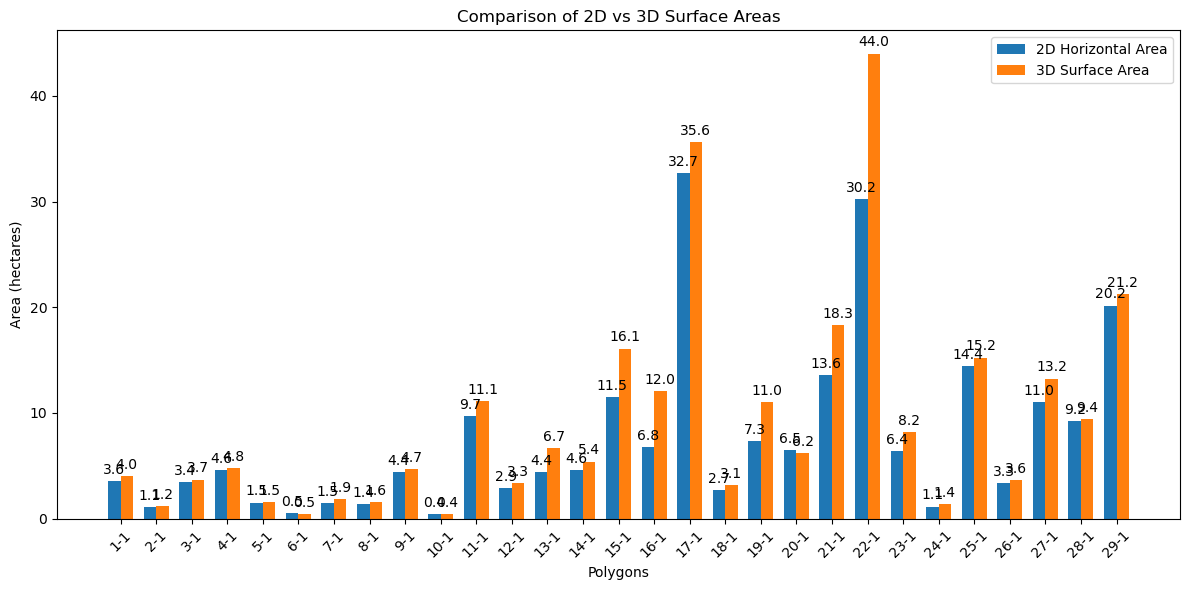

In [3]:
#This code is to calculate the surface area of polygons in a KML file considering elevation data from online APIs
import geopandas as gpd
import numpy as np
import requests
import time
from shapely.geometry import Polygon, Point
import matplotlib.pyplot as plt
from pyproj import CRS, Transformer
import json

class KMLSurfaceAreaCalculator:
    def __init__(self):
        self.elevation_api_urls = {
            'open_elevation': 'https://api.open-elevation.com/api/v1/lookup',
            'elevation_api': 'https://elevation-api.io/api/elevation',
            'open_topo': 'https://api.opentopodata.org/v1/aster30m'  # Requires specific datasets
        }
        
    def read_kml_file(self, kml_path):
        """Read KML file and return GeoDataFrame"""
        try:
            gdf = gpd.read_file(kml_path)
            print(f"Successfully loaded KML with {len(gdf)} polygon(s)")
            return gdf
        except Exception as e:
            print(f"Error reading KML: {e}")
            return None
    
    def get_elevation_batch(self, points, api_source='open_elevation'):
        """Get elevation for multiple points using batch API calls"""
        elevations = []
        
        if api_source == 'open_elevation':
            # Prepare locations for batch request
            locations = [{"latitude": lat, "longitude": lon} for lat, lon in points]
            
            # Split into batches of 100 (API limit)
            batch_size = 100
            for i in range(0, len(locations), batch_size):
                batch = locations[i:i + batch_size]
                payload = {"locations": batch}
                
                try:
                    response = requests.post(
                        self.elevation_api_urls[api_source],
                        json=payload,
                        headers={'Content-Type': 'application/json'},
                        timeout=30
                    )
                    
                    if response.status_code == 200:
                        data = response.json()
                        batch_elevations = [result['elevation'] for result in data['results']]
                        elevations.extend(batch_elevations)
                    else:
                        print(f"API error: {response.status_code}")
                        # Fill with zeros for failed batch
                        elevations.extend([0] * len(batch))
                        
                except Exception as e:
                    print(f"Request failed: {e}")
                    elevations.extend([0] * len(batch))
                
                # Be nice to the API
                time.sleep(0.5)
                
        return elevations
    
    def sample_points_in_polygon(self, polygon, samples_per_dimension=20):
        """Generate sample points within polygon for elevation sampling"""
        bounds = polygon.bounds
        min_x, min_y, max_x, max_y = bounds
        
        points = []
        sample_lats = np.linspace(min_y, max_y, samples_per_dimension)
        sample_lons = np.linspace(min_x, max_x, samples_per_dimension)
        
        for lat in sample_lats:
            for lon in sample_lons:
                point = Point(lon, lat)
                if polygon.contains(point):
                    points.append((lat, lon))
        
        print(f"Generated {len(points)} sample points within polygon")
        return points
    
    def calculate_surface_area_triangulation(self, points_3d):
        """Calculate surface area using 3D triangulation"""
        from scipy.spatial import Delaunay
        
        if len(points_3d) < 3:
            return 0
            
        # Convert to numpy array
        points_array = np.array(points_3d)
        
        # Perform 2D Delaunay triangulation on x,y coordinates
        tri = Delaunay(points_array[:, :2])
        
        total_area = 0
        for simplex in tri.simplices:
            # Get the three points of the triangle
            A, B, C = points_array[simplex]
            
            # Calculate area of 3D triangle using cross product method
            AB = B - A
            AC = C - A
            cross_product = np.cross(AB, AC)
            triangle_area = 0.5 * np.linalg.norm(cross_product)
            total_area += triangle_area
        
        return total_area
    
    def calculate_2d_area(self, polygon):
        """Calculate 2D planar area in hectares"""
        # Convert to UTM for accurate area calculation
        centroid = polygon.centroid
        utm_zone = int((centroid.x + 180) / 6) + 1
        hemisphere = 'north' if centroid.y >= 0 else 'south'
        epsg_code = 32600 + utm_zone if hemisphere == 'north' else 32700 + utm_zone
        
        try:
            transformer = Transformer.from_crs('EPSG:4326', f'EPSG:{epsg_code}', always_xy=True)
            poly_utm = Polygon([transformer.transform(x, y) for x, y in polygon.exterior.coords])
            area_sq_m = poly_utm.area
            area_hectares = area_sq_m / 10000
            return area_hectares
        except:
            # Fallback to approximate calculation
            return polygon.area * 111319.488 * 111319.488 / 10000  # Rough conversion
    
    def calculate_surface_area(self, kml_path, samples_per_dimension=15, api_source='open_elevation'):
        """Main function to calculate surface area with elevation data"""
        
        # Read KML file
        gdf = self.read_kml_file(kml_path)
        if gdf is None:
            return None
        
        results = []
        
        for idx, row in gdf.iterrows():
            polygon = row.geometry
            
            if polygon.geom_type not in ['Polygon', 'MultiPolygon']:
                print(f"Skipping non-polygon geometry: {polygon.geom_type}")
                continue
            
            # Handle MultiPolygon by processing each polygon separately
            if polygon.geom_type == 'MultiPolygon':
                polygons = list(polygon.geoms)
            else:
                polygons = [polygon]
            
            for poly_idx, poly in enumerate(polygons):
                print(f"\nProcessing polygon {idx+1}-{poly_idx+1}...")
                
                # Calculate 2D area
                area_2d_ha = self.calculate_2d_area(poly)
                print(f"2D Horizontal Area: {area_2d_ha:.2f} hectares")
                
                # Sample points within polygon
                points_2d = self.sample_points_in_polygon(poly, samples_per_dimension)
                
                if len(points_2d) < 3:
                    print("Not enough points for surface area calculation")
                    results.append({
                        'polygon': f"{idx+1}-{poly_idx+1}",
                        'area_2d_ha': area_2d_ha,
                        'area_3d_ha': area_2d_ha,
                        'ratio': 1.0,
                        'points_sampled': len(points_2d),
                        'status': 'insufficient_points'
                    })
                    continue
                
                # Get elevations for sampled points
                print("Fetching elevation data...")
                elevations = self.get_elevation_batch(points_2d, api_source)
                
                # Convert to 3D points (lat, lon, elevation)
                points_3d = []
                valid_points = 0
                for (lat, lon), elev in zip(points_2d, elevations):
                    if elev > -100:  # Filter out invalid elevations (ocean depths, errors)
                        # Convert to meters in local tangent plane (approximate)
                        # This is a simplification but works for small areas
                        x = lon * 111319.488  # meters per degree longitude (at equator)
                        y = lat * 111319.488  # meters per degree latitude
                        points_3d.append([x, y, elev])
                        valid_points += 1
                
                print(f"Valid elevation points: {valid_points}/{len(points_2d)}")
                
                if valid_points < 3:
                    print("Not enough valid elevation data")
                    results.append({
                        'polygon': f"{idx+1}-{poly_idx+1}",
                        'area_2d_ha': area_2d_ha,
                        'area_3d_ha': area_2d_ha,
                        'ratio': 1.0,
                        'points_sampled': valid_points,
                        'status': 'insufficient_elevation_data'
                    })
                    continue
                
                # Calculate 3D surface area
                area_3d_sq_m = self.calculate_surface_area_triangulation(points_3d)
                area_3d_ha = area_3d_sq_m / 10000
                
                ratio = area_3d_ha / area_2d_ha if area_2d_ha > 0 else 1.0
                
                print(f"3D Surface Area: {area_3d_ha:.2f} hectares")
                print(f"Area Ratio (3D/2D): {ratio:.2f}")
                
                results.append({
                    'polygon': f"{idx+1}-{poly_idx+1}",
                    'area_2d_ha': area_2d_ha,
                    'area_3d_ha': area_3d_ha,
                    'ratio': ratio,
                    'points_sampled': valid_points,
                    'status': 'success'
                })
        
        return results
    
    def plot_results(self, results):
        """Plot comparison between 2D and 3D areas"""
        if not results:
            return
            
        polygons = [r['polygon'] for r in results]
        areas_2d = [r['area_2d_ha'] for r in results]
        areas_3d = [r['area_3d_ha'] for r in results]
        
        x = np.arange(len(polygons))
        width = 0.35
        
        fig, ax = plt.subplots(figsize=(12, 6))
        bars1 = ax.bar(x - width/2, areas_2d, width, label='2D Horizontal Area')
        bars2 = ax.bar(x + width/2, areas_3d, width, label='3D Surface Area')
        
        ax.set_xlabel('Polygons')
        ax.set_ylabel('Area (hectares)')
        ax.set_title('Comparison of 2D vs 3D Surface Areas')
        ax.set_xticks(x)
        ax.set_xticklabels(polygons)
        ax.legend()
        
        # Add value labels on bars
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                ax.annotate(f'{height:.1f}',
                           xy=(bar.get_x() + bar.get_width() / 2, height),
                           xytext=(0, 3),
                           textcoords="offset points",
                           ha='center', va='bottom')
        
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# Usage Example
def main():
    calculator = KMLSurfaceAreaCalculator()
    
    # Calculate surface area for your KML file
    kml_file_path = r"C:\Users\ganes\Downloads\Farm Boundary MP.kml" # Replace with your KML file path
    
    results = calculator.calculate_surface_area(
        kml_file_path, 
        samples_per_dimension=20,  # More samples = more accuracy but slower
        api_source='open_elevation'
    )
    
    # Print summary
    if results:
        print("\n" + "="*50)
        print("SUMMARY RESULTS")
        print("="*50)
        
        total_2d = sum(r['area_2d_ha'] for r in results)
        total_3d = sum(r['area_3d_ha'] for r in results)
        overall_ratio = total_3d / total_2d if total_2d > 0 else 1.0
        
        print(f"Total 2D Area: {total_2d:.2f} hectares")
        print(f"Total 3D Surface Area: {total_3d:.2f} hectares")
        print(f"Overall 3D/2D Ratio: {overall_ratio:.2f}")
        
        # Plot results
        calculator.plot_results(results)
    
    return results

# Run the analysis
if __name__ == "__main__":
    results = main()

In [47]:
# this code is to  fix invalid kml geometries 
# KML FIXER – ATTRIBUTE SAFE (KML → GPKG → FIX → KML)
# =============================================================================

import subprocess
import geopandas as gpd
from shapely.validation import make_valid
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# -----------------------------------------------------------------------------
# INPUT
# -----------------------------------------------------------------------------
KML_INPUT = r"C:\Users\ganes\Desktop\24-25 Jharkhand\Recorded_shp\GP_mergeds.kml"

# -----------------------------------------------------------------------------
# OUTPUT FILES (auto-generated)
# -----------------------------------------------------------------------------
kml_path = Path(KML_INPUT)
gpkg_raw = kml_path.with_suffix(".gpkg")
gpkg_fixed = kml_path.with_name(kml_path.stem + "_FIXED.gpkg")
kml_fixed = kml_path.with_name(kml_path.stem + "_FIXED.kml")

# -----------------------------------------------------------------------------
# STEP 1: KML → GPKG (preserves ExtendedData & styles)
# -----------------------------------------------------------------------------
print("\n🔁 Step 1: Converting KML → GeoPackage (safe attributes)")

subprocess.run(
    ["ogr2ogr", "-f", "GPKG", str(gpkg_raw), KML_INPUT],
    check=True
)

# -----------------------------------------------------------------------------
# STEP 2: FIX GEOMETRIES (GeoPandas + Shapely)
# -----------------------------------------------------------------------------
print("\n🔧 Step 2: Fixing geometries")

layers = gpd.list_layers(gpkg_raw)
layer_name = layers.name.iloc[0]

gdf = gpd.read_file(gpkg_raw, layer=layer_name)

print(f"📊 Features: {len(gdf)}")
print(f"🧾 Attributes preserved: {list(gdf.columns)}")

def fix_geom(geom):
    if geom is None or geom.is_empty:
        return geom
    try:
        g = geom.buffer(0)
        if not g.is_valid:
            g = make_valid(geom)
        return g
    except Exception:
        return geom

gdf["geometry"] = gdf.geometry.apply(fix_geom)
gdf = gdf[gdf.geometry.is_valid]

gdf.to_file(gpkg_fixed, driver="GPKG")

print(f"✅ Fixed geometries saved to {gpkg_fixed.name}")

# -----------------------------------------------------------------------------
# STEP 3: GPKG → KML (attributes + styles preserved)
# -----------------------------------------------------------------------------
print("\n🔁 Step 3: Converting GeoPackage → KML")

subprocess.run(
    ["ogr2ogr", "-f", "KML", str(kml_fixed), str(gpkg_fixed)],
    check=True
)

print("\n🎉 DONE!")
print("✔ Geometries fixed")
print("✔ ALL attributes preserved (layer names, styles, path, etc.)")
print(f"📁 Final KML: {kml_fixed}")



🔁 Step 1: Converting KML → GeoPackage (safe attributes)

🔧 Step 2: Fixing geometries
📊 Features: 16
🧾 Attributes preserved: ['Name', 'description', 'timestamp', 'begin', 'end', 'altitudeMode', 'tessellate', 'extrude', 'visibility', 'drawOrder', 'icon', 'cmt', 'desc', 'src', 'link1_href', 'link1_text', 'link1_type', 'link2_href', 'link2_text', 'link2_type', 'number', 'type', 'line', 'locus_acti', 'layer', 'path', 'geometry']
✅ Fixed geometries saved to GP_mergeds_FIXED.gpkg

🔁 Step 3: Converting GeoPackage → KML

🎉 DONE!
✔ Geometries fixed
✔ ALL attributes preserved (layer names, styles, path, etc.)
📁 Final KML: C:\Users\ganes\Desktop\24-25 Jharkhand\Recorded_shp\GP_mergeds_FIXED.kml


In [58]:
# Enhanced Eligibility Analysis - Continuous Forest & 2m Canopy
import geemap
import ee
from datetime import datetime

# Initialize Earth Engine
ee.Initialize()

Map = geemap.Map()
Map.add_basemap('HYBRID')

Dynamic_World = ee.ImageCollection('GOOGLE/DYNAMICWORLD/V1')
roi = ee.FeatureCollection("projects/ee-clivedcosta/assets/Jharkhandmerged")
Map.centerObject(roi)
scale = 10

# Define analysis period (2016-2022)
analysis_years = list(range(2016, 2023))

def get_yearly_landcover(year):
    """Get annual land cover classification"""
    start_date = f'{year}-01-01'
    end_date = f'{year}-12-31'
    
    yearly_data = Dynamic_World.filterBounds(roi) \
        .filterDate(start_date, end_date) \
        .select('label') \
        .mode()
    
    return yearly_data

# Generate yearly land cover
print("Processing land cover data 2016-2022...")
yearly_landcover = {}
for year in analysis_years:
    yearly_landcover[year] = get_yearly_landcover(year)

# Create forest masks for each year
forest_masks = {}
for year in analysis_years:
    forest_masks[year] = yearly_landcover[year].eq(1)  # Trees class

# NEW: Detect CONTINUOUSLY FORESTED areas (avoid anomalies)
print("Identifying continuously forested areas...")

# Areas forested in at least 3 years (more reliable than single years)
def get_continuous_forest_mask(min_years=3):
    """Find areas that were forest for at least N years (any years)"""
    
    total_forest_years = forest_masks[2016]
    for year in range(2017, 2023):
        total_forest_years = total_forest_years.add(forest_masks[year])
    
    # Areas forest in at least min_years
    continuous_forest = total_forest_years.gte(min_years)
    return continuous_forest

# Use areas forest in at least 3 years as "continuous forest"
continuous_forest = get_continuous_forest_mask(min_years=3)

# SIMPLIFIED LOGIC: Only exclude continuous forest (not 2016-2018 baseline)
was_ever_continuous_forest = continuous_forest

# Current (2022) - Non-eligible if currently forest
current_2022 = yearly_landcover[2022]
non_eligible_current = current_2022.eq(1)  # Trees(1)

# Final eligibility: Was NOT continuous forest AND is NOT forest currently
eligible_areas = was_ever_continuous_forest.Not().And(non_eligible_current.Not())

# CANOPY HEIGHT EXCLUSION - Using 2m threshold
canopy_height = ee.ImageCollection(
    'projects/meta-forest-monitoring-okw37/assets/CanopyHeight'
).mosaic().clip(roi)

# Areas with canopy height >=2m are excluded (existing woody biomass)
canopy_exclusion = canopy_height.gte(2)

# Conservative eligibility (with canopy check)
final_eligible = eligible_areas.And(canopy_exclusion.Not())

# Convert to vectors
def clip_eligible_to_polygon(feature):
    geometry = feature.geometry()
    poly_eligible_mask = final_eligible.clip(geometry)
    
    eligible_vectors = poly_eligible_mask.selfMask().reduceToVectors(
        geometry=geometry,
        scale=scale,
        geometryType='polygon',
        crs='EPSG:4326',
        bestEffort=True,
        maxPixels=1e13
    )
    
    eligible_with_props = eligible_vectors.map(
        lambda eligible_feature: eligible_feature.set(feature.toDictionary())
    )
    
    return eligible_with_props

all_eligible_parts = roi.map(clip_eligible_to_polygon).flatten()

# VISUALIZATION
vis_params_dw = {
    'bands': ['label'],
    'palette': [
        '#419BDF', '#397D49', '#88B053', '#7A87C6', '#E49635', 
        '#DFC35A', '#C4281B', '#A59B8F', '#B39FE1'
    ],
    'min': 0,
    'max': 8
}

# Add key layers for analysis
Map.addLayer(yearly_landcover[2016].clip(roi), vis_params_dw, '2016 Baseline')
Map.addLayer(yearly_landcover[2022].clip(roi), vis_params_dw, '2022 Current')
Map.addLayer(
    continuous_forest.selfMask().clip(roi),
    {'palette': ['red']},
    'Continuous Forest (3+ years)',
    False
)
Map.addLayer(
    canopy_height,
    {'min': 0, 'max': 20, 'palette': ['white', 'green']},
    'Canopy Height (m)',
    False
)

# Eligible areas
Map.addLayer(
    final_eligible.selfMask().clip(roi),
    {'palette': ['00FF00']},
    'Eligible Areas (Raster)'
)
Map.addLayer(
    all_eligible_parts,
    {'color': '00FF00', 'fillColor': '00FF0044'},
    'Eligible Areas (Vector)'
)

# AREA CALCULATIONS
print("=== AREA ANALYSIS ===")

# Total area
total_area = roi.geometry().area().divide(10000)
total_ha = total_area.getInfo()
print(f"Total area: {total_ha:.2f} hectares")

# Forest area by year
print("\nForest area by year:")
for year in analysis_years:
    forest_area = forest_masks[year].multiply(ee.Image.pixelArea()) \
        .reduceRegion(
            reducer=ee.Reducer.sum(),
            geometry=roi,
            scale=scale
        ).get('label')
    forest_ha = ee.Number(forest_area).divide(10000).getInfo()
    print(f"  {year}: {forest_ha:.2f} ha")

# Continuous forest area
continuous_forest_area = continuous_forest.multiply(ee.Image.pixelArea()) \
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=roi,
        scale=scale
    ).get('label')
continuous_forest_ha = ee.Number(continuous_forest_area).divide(10000).getInfo()

# Current forest area (2022)
current_forest_area = non_eligible_current.multiply(ee.Image.pixelArea()) \
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=roi,
        scale=scale
    ).get('label')
current_forest_ha = ee.Number(current_forest_area).divide(10000).getInfo()

# Canopy exclusion area
canopy_excl_area = canopy_exclusion.multiply(ee.Image.pixelArea()) \
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=roi,
        scale=scale
    ).get('cover_code')
canopy_excl_ha = ee.Number(canopy_excl_area).divide(10000).getInfo()

# Final eligible area
final_eligible_area = final_eligible.multiply(ee.Image.pixelArea()) \
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=roi,
        scale=scale
    ).get('label')
final_eligible_ha = ee.Number(final_eligible_area).divide(10000).getInfo()

print(f"\n=== EXCLUSION SUMMARY ===")
print(f"Total area: {total_ha:.2f} ha")
print(f"Excluded - Continuous forest (3+ years): {continuous_forest_ha:.2f} ha")
print(f"Excluded - Current forest (2022): {current_forest_ha:.2f} ha")
print(f"Excluded - Canopy height >=2m: {canopy_excl_ha:.2f} ha")

print(f"\n{'='*60}")
print(f"FINAL ELIGIBLE AREA FOR A/R R PROJECT (2022): {final_eligible_ha:.2f} HECTARES")
print(f"{'='*60}")

print(f"\n=== BREAKDOWN ===")
print(f"Total area: {total_ha:.2f} ha")
print(f"Total excluded: {(total_ha - final_eligible_ha):.2f} ha")
print(f"Eligible area: {final_eligible_ha:.2f} ha ({final_eligible_ha/total_ha*100:.1f}% of total)")

print(f"\n=== METHODOLOGY ===")
print("✓ Excludes areas that were forest in 3+ years (avoiding 1-year anomalies)")
print("✓ Excludes areas that are currently forest (2022)")
print("✓ Excludes areas with canopy height >=2m (existing trees)")
print("✓ Uses only continuous forest (removed 2016-2018 baseline as requested)")

# Export results
export_task = ee.batch.Export.table.toDrive(
    collection=all_eligible_parts,
    description='jharkhand-1.2m',
    folder='GEE_Exports_2022_Jharkhand_1.2M',
    fileFormat='KML'
)

export_task.start()
print("\nExport started: continuous_forest_only_2m_canopy_2022.kml")

# Display map
Map.addLayerControl()
Map


Processing land cover data 2016-2022...
Identifying continuously forested areas...
=== AREA ANALYSIS ===
Total area: 540.62 hectares

Forest area by year:
  2016: 194.69 ha
  2017: 238.72 ha
  2018: 222.69 ha
  2019: 182.42 ha
  2020: 223.70 ha
  2021: 224.52 ha
  2022: 276.75 ha

=== EXCLUSION SUMMARY ===
Total area: 540.62 ha
Excluded - Continuous forest (3+ years): 247.74 ha
Excluded - Current forest (2022): 276.75 ha
Excluded - Canopy height >=2m: 58.77 ha

FINAL ELIGIBLE AREA FOR A/R R PROJECT (2022): 243.10 HECTARES

=== BREAKDOWN ===
Total area: 540.62 ha
Total excluded: 297.52 ha
Eligible area: 243.10 ha (45.0% of total)

=== METHODOLOGY ===
✓ Excludes areas that were forest in 3+ years (avoiding 1-year anomalies)
✓ Excludes areas that are currently forest (2022)
✓ Excludes areas with canopy height >=2m (existing trees)
✓ Uses only continuous forest (removed 2016-2018 baseline as requested)

Export started: continuous_forest_only_2m_canopy_2022.kml


Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…